#### Dataset
- Name: Titanic Dataset
- Source: Kaggle
- Reference: Link: https://www.kaggle.com/c/titanic


<h1> Feature Engineering

In the EDA, we observed that some features contain potential information but are not suitable in their raw form.

FamilySize</br>
IsAlone</br>
Title extraction</br>
Deck extraction</br>
FarePerPerson</br>

For Example:

SibSp and Parch

These are two separate columns:

SibSp = Number of siblings or spouses</br>
Parch = Number of parents or children

However, a factor that might be truly important for survival is:

The size of the family the passenger traveled with.

So, we create a new feature:

$$ FamilySize = SibSp + Parch + 1 $$

The number 1 represents the passenger themselves.

For example:

Braund, Mr. Owen Harris

Cumings, Mrs. John Bradley

The full name might not be important, but the title is:

Mr, Mrs, Miss, Master

Because it indicates:

Gender, Approximate age, Social status

For example:

In the EDA, we observed:

Cabin
687 missing

However, the existing values ​​are:

C85, E46, B28

They contain Deck information:

C, E, B

Thus:

$$ Cabin \rightarrow Deck $$

For example:

Fare

We have a raw 'Fare' value:

Fare = 512

However, if two people share a cabin or are traveling as a family, the total 'Fare' figure can be misleading.

Feature:

$$ FarePerPerson = \frac{Fare}{FamilySize} $$

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [47]:
path = "../../datasets/Titanic-Dataset/raw/Titanic-Dataset.csv"

df = pd.read_csv(path)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
df_fe = df.copy()

<h3> Step 1: Number of people and family details </h3> 

<h3> Feature 1 — FamilySize </h3>

In [49]:
df_fe["FamilySize"] = (
    df_fe["SibSp"]
    +
    df_fe["Parch"]
    +
    1
)

In [50]:
df_fe[
    [
        "SibSp",
        "Parch",
        "FamilySize"
    ]
].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


<h3> Feature 2 — IsAlone </h3>

In [51]:
df_fe["IsAlone"] = (
    df_fe["FamilySize"] == 1
).astype(int)

In [52]:
df_fe[
    [
        "FamilySize",
        "IsAlone"
    ]
].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


<h3> Feature 3 — Family Category </h3>

This is a classic case of feature engineering.

Because:

very small families,</br>
medium-sized families, and</br>
large families

might exhibit different behaviors.

In [53]:
def family_category(size):

    if size == 1:
        return "Alone"

    elif size <= 4:
        return "Small"

    else:
        return "Large"

In [54]:
df_fe["FamilyCategory"] = (
    df_fe["FamilySize"]
    .apply(family_category)
)

df_fe["FamilyCategory"].value_counts()

FamilyCategory
Alone    537
Small    292
Large     62
Name: count, dtype: int64

In [55]:
df_fe[
[
"SibSp",
"Parch",
"FamilySize",
"IsAlone",
"FamilyCategory"
]
].head(10)

,SibSp,Parch,FamilySize,IsAlone,FamilyCategory
0,1,0,2,0,Small
1,1,0,2,0,Small
2,0,0,1,1,Alone
3,1,0,2,0,Small
4,0,0,1,1,Alone
5,0,0,1,1,Alone
6,0,0,1,1,Alone
7,3,1,5,0,Large
8,0,2,3,0,Small
9,1,0,2,0,Small


In [56]:
df_fe["FamilyCategory"].value_counts()

FamilyCategory
Alone    537
Small    292
Large     62
Name: count, dtype: int64

Is `FamilySize` always better?

Not necessarily.

Sometimes:

`SibSp`
`Parch`
`FamilySize`
`IsAlone`

Including them all simultaneously might introduce redundant information.

For example:

$$ FamilySize = SibSp + Parch + 1 $$

Thus, these three features are not entirely independent.

Later, during feature selection, we will examine which ones are truly helpful.

<h3> FamilyCategory vs Survival </h3>

In [57]:
family_survival = pd.crosstab(
    df_fe["FamilyCategory"],
    df_fe["Survived"],
    normalize="index"
)

family_survival

Survived,0,1
FamilyCategory,,
Alone,0.696462,0.303538
Large,0.838710,0.161290
Small,0.421233,0.578767


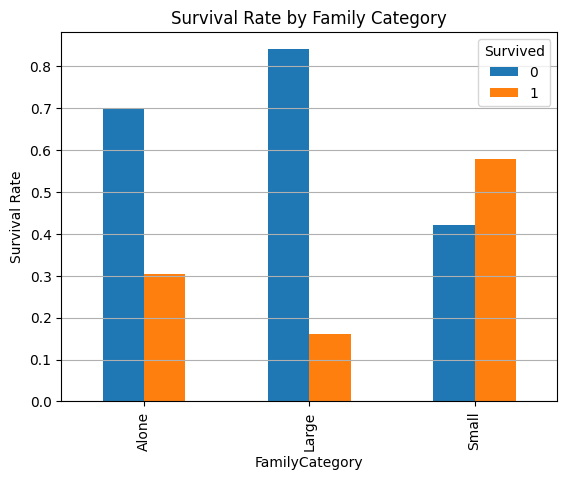

In [58]:
family_survival.plot(
    kind="bar"
)

plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Category")
plt.grid(axis="y")
plt.show()

The precise goal of feature engineering is to transform raw variables into features that are more meaningful for the problem at hand.

#### Family Feature Analysis

Family-related features were created based on the observations from EDA.

FamilySize was calculated as:

FamilySize = SibSp + Parch + 1

Additionally, passengers were categorized into three groups:
- Alone</br>
- Small family</br>
- Large family


The analysis showed that passengers traveling with small families had higher
survival rates compared with passengers traveling alone or with large families.

Large families demonstrated the lowest survival rate, although this group
contains fewer observations and should be interpreted carefully.

These findings suggest that family-related information may provide useful
predictive signals for machine learning models.

<h3> Step 2: Name and Position Characteristics </h3>

<h3> NameCategory vs Survival </h3>

These titles can provide information regarding:

gender</br>
approximate age</br>
social status</br>
family position

In [59]:
df_fe["Name"].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [60]:
def extract_title(name):

    match = re.search(
        r",\s*([^.]*)\.",
        name
    )

    if match:
        return match.group(1)

    return None

In [61]:
df_fe["Title"] = (
    df_fe["Name"]
    .apply(extract_title)
)

In [62]:
df_fe[
    [
        "Name",
        "Title"
    ]
].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [63]:
df_fe["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

We merge the "Rare" titles because some of them appear very infrequently—for example:

Lady, Countess, Jonkheer, Sir, Capt, Col

Using one-hot encoding would result in features with very few samples; therefore, we typically group these rare titles under the label "Rare."

In [64]:
def simplify_title(title):

    common_titles = [
        "Mr",
        "Miss",
        "Mrs",
        "Master"
    ]

    if title in common_titles:
        return title

    else:
        return "Rare"

In [65]:
df_fe["Title"] = (
    df_fe["Title"]
    .apply(simplify_title)
)

In [66]:
df_fe[["Name","Title"]].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [67]:
df_fe["Title"].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Examining the Relationship Between Title and Survival

In [68]:
title_survival = pd.crosstab(
    df_fe["Title"],
    df_fe["Survived"],
    normalize="index"
)

title_survival

Survived,0,1
Title,,
Master,0.425000,0.575000
Miss,0.302198,0.697802
Mr,0.843327,0.156673
Mrs,0.208000,0.792000
Rare,0.555556,0.444444


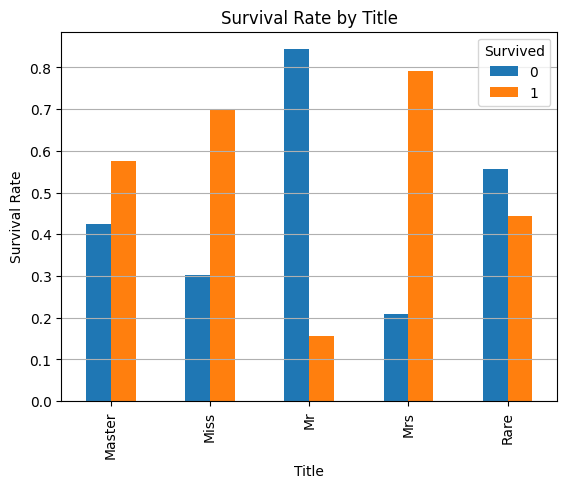

In [69]:
title_survival.plot(
    kind="bar"
)

plt.ylabel(
    "Survival Rate"
)

plt.title(
    "Survival Rate by Title"
)

plt.grid(axis="y")

plt.show()

<h3> Survival Rate by Title </h3>

| Title  | Not Survived | Survived |
| ------ | -----------: | -------: |
| Master |        42.5% |    57.5% |
| Miss   |        30.2% |    69.8% |
| Mr     |        84.3% |    15.7% |
| Mrs    |        20.8% |    79.2% |
| Rare   |        55.6% |    44.4% |


#### Title Feature Extraction

The Name feature contains additional information in the form of passenger
titles (e.g., Mr, Mrs, Miss, Master). These titles may represent gender,
age group, and social status information.

A new feature named Title was extracted from the Name column using pattern
matching. Rare titles with very few observations were grouped into a single
Rare category to reduce sparsity.

The survival analysis showed clear differences between title groups.
Passengers with titles such as Mrs and Miss had considerably higher survival
rates, while Mr showed a much lower survival rate. Master also demonstrated
a distinct survival pattern compared with adult male passengers.

These results indicate that Title provides meaningful information beyond the
original Sex feature and can improve model representation.

<h3> Step 3: Location feature </h3>

<h3> Cabin → Deck Extraction </h3>

Cbin = Deck + Number

In [70]:
df_fe["Cabin"].head(20)

0      NaN
1      C85
2      NaN
3     C123
4      NaN
5      NaN
6      E46
7      NaN
8      NaN
9      NaN
10      G6
11    C103
12     NaN
13     NaN
14     NaN
15     NaN
16     NaN
17     NaN
18     NaN
19     NaN
Name: Cabin, dtype: object

In [71]:
def extract_deck(cabin):

    if pd.isna(cabin):
        return "Unknown"

    return cabin[0]

In [72]:
df_fe["Deck"] = (
    df_fe["Cabin"]
    .apply(extract_deck)
)

In [73]:
df_fe[
    [
        "Cabin",
        "Deck"
    ]
].head(20)

,Cabin,Deck
0,NaN,Unknown
1,C85,C
2,NaN,Unknown
3,C123,C
4,NaN,Unknown
5,NaN,Unknown
6,E46,E
7,NaN,Unknown
8,NaN,Unknown
9,NaN,Unknown


In [74]:
df_fe["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [75]:
deck_survival = pd.crosstab(
    df_fe["Deck"],
    df_fe["Survived"],
    normalize="index"
)

deck_survival

Survived,0,1
Deck,,
A,0.533333,0.466667
B,0.255319,0.744681
C,0.406780,0.593220
D,0.242424,0.757576
E,0.250000,0.750000
F,0.384615,0.615385
G,0.500000,0.500000
T,1.000000,0.000000
Unknown,0.700146,0.299854


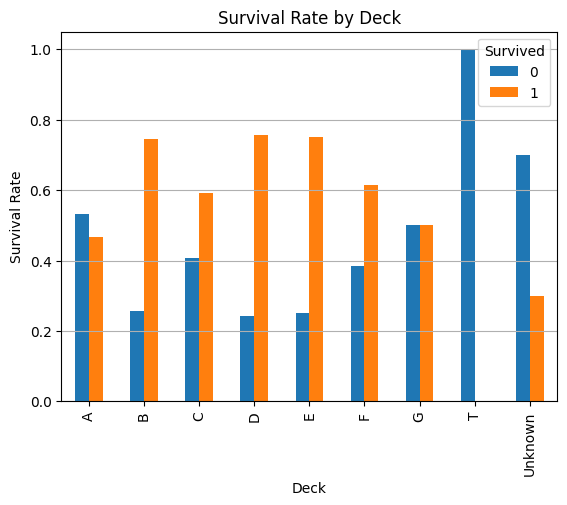

In [76]:
deck_survival.plot(
    kind="bar"
)

plt.ylabel(
    "Survival Rate"
)

plt.title(
    "Survival Rate by Deck"
)

plt.grid(axis="y")

plt.show()

#### Deck Feature Extraction

The Cabin feature contained a large proportion of missing values.
Instead of directly removing this feature, the first character of the
Cabin value was extracted to represent the passenger deck.

Missing Cabin values were assigned to an "Unknown" category.

The analysis showed differences in survival rates among different decks.
Passengers with recorded cabin information generally showed different
survival patterns compared with passengers without cabin information.

However, some deck categories contain very few observations. Therefore,
rare categories should be handled carefully during preprocessing to avoid
overfitting.

<h3> Step 4: Ticket price feature </h3>

<h3> Fare → FarePerPerson </h3>

If a family of five purchases a group ticket, the raw fare might be misleading, so we calculate:

$$ FarePerPerson = \frac{Fare}{FamilySize} $$

In [77]:
df_fe["FarePerPerson"] = (
    df_fe["Fare"]
    /
    df_fe["FamilySize"]
)

In [78]:
df_fe[
    [
        "Fare",
        "FamilySize",
        "FarePerPerson"
    ]
].head(10)

,Fare,FamilySize,FarePerPerson
0,7.2500,2,3.62500
1,71.2833,2,35.64165
2,7.9250,1,7.92500
3,53.1000,2,26.55000
4,8.0500,1,8.05000
5,8.4583,1,8.45830
6,51.8625,1,51.86250
7,21.0750,5,4.21500
8,11.1333,3,3.71110
9,30.0708,2,15.03540


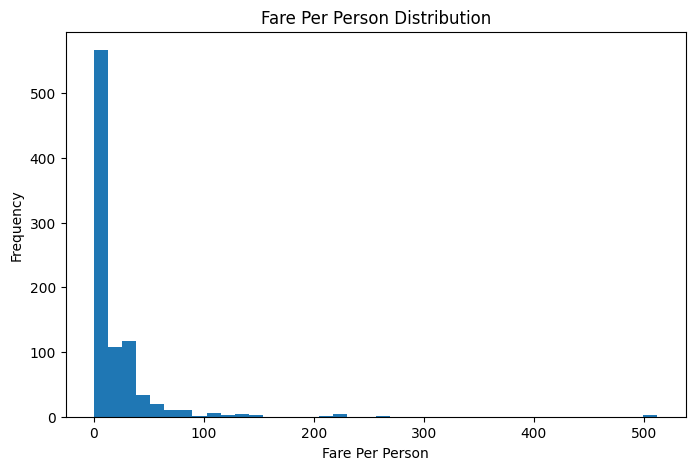

In [79]:
plt.figure(figsize=(8,5))

plt.hist(
    df_fe["FarePerPerson"],
    bins=40
)

plt.xlabel(
    "Fare Per Person"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Fare Per Person Distribution"
)

plt.show()

Analyzing the relationship with survival

In [80]:
df_fe["FareGroup"] = pd.qcut(
    df_fe["FarePerPerson"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [81]:
fare_survival = pd.crosstab(
    df_fe["FareGroup"],
    df_fe["Survived"],
    normalize="index"
)

fare_survival

Survived,0,1
FareGroup,,
Low,0.734513,0.265487
Medium,0.745455,0.254545
High,0.591928,0.408072
Very High,0.391892,0.608108


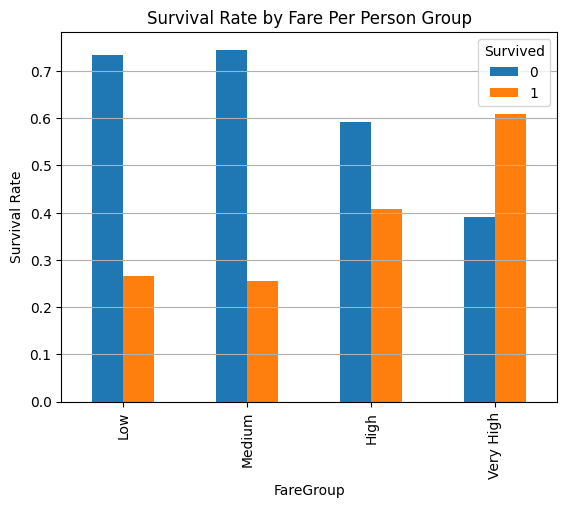

In [82]:
fare_survival.plot(
    kind="bar"
)

plt.ylabel(
    "Survival Rate"
)

plt.title(
    "Survival Rate by Fare Per Person Group"
)

plt.grid(
    axis="y"
)

plt.show()

We currently have two features:

Fare</br>
FarePerPerson

For now, we keep both.

Because in the next stage—Feature Selection—we will examine:

Do they contain redundant information?</br>
Which features are truly helpful?</br>
Would removing some of them improve the model?

| Group     |  Dead | Survived |
| --------- | ----: | -------: |
| Low       | 73.4% |    26.5% |
| Medium    | 74.5% |    25.4% |
| High      | 59.2% |    40.8% |
| Very High | 39.1% |    60.8% |


An important ML point:

We currently have several features that contain similar information:

For example:

Fare</br>
Pclass</br>
Deck</br>
FarePerPerson

They might all convey an underlying concept:

Socioeconomic Status

During the feature selection stage, we examine:

Which ones are truly helpful?</br>
Are some of them redundant?</br>
Does removing certain features improve performance?

### Feature Engineering Summary


Original → New Feature

| Original          | Engineered Feature |
| ----------------- | ------------------ |
| SibSp + Parch     | FamilySize         |
| FamilySize        | IsAlone            |
| FamilySize        | FamilyCategory     |
| Name              | Title              |
| Cabin             | Deck               |
| Fare + FamilySize | FarePerPerson      |


<h3> Step 5: Saving the CSV results </h3>

In [83]:
numeric_features = [
    "Age",
    "Fare",
    "FamilySize",
    "FarePerPerson",
    "SibSp",
    "Parch"
]

categorical_features = [
    "Sex",
    "Embarked",
    "FamilyCategory",
    "Title",
    "Deck"
]

target = "Survived"

Dropping unnecessary raw features

We are dropping the following:

PassengerId</br>
Name</br>
Ticket</br>
Cabin

Because:

PassengerId → It is an identifier</br>
Name → Converted to 'Title'</br>
Cabin → Converted to 'Deck'</br>
Ticket → Has not undergone feature engineering yet and has high cardinality

In [84]:
final_columns = [
    "Survived",

    # Numerical
    "Age",
    "Fare",
    "FamilySize",
    "FarePerPerson",
    "SibSp",
    "Parch",

    # Categorical
    "Sex",
    "Embarked",
    "FamilyCategory",
    "Title",
    "Deck"
]


df_final = df_fe[
    final_columns
].copy()

In [85]:
df_final.head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


In [86]:
df_final.isnull().sum()

Survived            0
Age               177
Fare                0
FamilySize          0
FarePerPerson       0
SibSp               0
Parch               0
Sex                 0
Embarked            2
FamilyCategory      0
Title               0
Deck                0
dtype: int64

Approximately 20% of the age values ​​are missing.

This is a problem, but we shouldn't fix it here.

Why?

Because this file—

titanic_feature_engineered.csv

—is the feature-engineered version, not the final model version.

In [87]:
output_path = (
    "../../datasets/"
    "Titanic-Dataset/"
    "processed/"
    "titanic_feature_engineered.csv"
)


df_final.to_csv(
    output_path,
    index=False
)

In [88]:
pd.read_csv(
    output_path
).head()

,Survived,Age,Fare,FamilySize,FarePerPerson,SibSp,Parch,Sex,Embarked,FamilyCategory,Title,Deck
0,0,22.0,7.2500,2,3.62500,1,0,male,S,Small,Mr,Unknown
1,1,38.0,71.2833,2,35.64165,1,0,female,C,Small,Mrs,C
2,1,26.0,7.9250,1,7.92500,0,0,female,S,Alone,Miss,Unknown
3,1,35.0,53.1000,2,26.55000,1,0,female,S,Small,Mrs,C
4,0,35.0,8.0500,1,8.05000,0,0,male,S,Alone,Mr,Unknown


In [89]:
df_final.shape

(891, 12)

#### Summary

In this notebook, feature engineering techniques were applied to transform
raw Titanic variables into more meaningful representations.

The following features were created:

- FamilySize: Total number of family members traveling together.
- IsAlone: Indicates whether a passenger traveled alone.
- FamilyCategory: Groups passengers based on family size.
- Title: Extracted from passenger names to capture social and demographic information.
- Deck: Extracted from Cabin information.
- FarePerPerson: Normalized fare based on family size.

The resulting dataset contains 891 samples and 12 features including the target
variable Survived.

The generated dataset was saved as:

`titanic_feature_engineered.csv`

This dataset will be used for further feature selection and machine learning tasks.